#Datos del alumno
Alumno: Octavio Quintero Flores

Matricula: 266226

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Carga

In [20]:
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/AirQuality.csv',sep=";")
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


## Análisis Exploratorio de Datos (EDA) - AirQuality

## Introducción

El dataset **AirQuality** contiene mediciones horarias de calidad del aire, incluyendo concentraciones de contaminantes y variables climáticas.

Este dataset es comúnmente utilizado para analizar la relación entre condiciones ambientales y niveles de contaminación.

### Variables principales:

- CO(GT): Monóxido de carbono
- NOx(GT): Óxidos de nitrógeno
- C6H6(GT): Benceno
- T: Temperatura
- RH: Humedad relativa
- AH: Humedad absoluta

Antes del análisis, se realizara un proceso de limpieza debido a inconsistencias en los datos y errores en el formato numérico.

In [21]:
df.describe()

,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,1048.990061,-159.090093,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,NaN,NaN
std,329.832710,139.789093,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,921.000000,-200.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,NaN,NaN
50%,1053.000000,-200.000000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,NaN,NaN
75%,1221.000000,-200.000000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,NaN,NaN
max,2040.000000,1189.000000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,NaN,NaN


Durante la exploración de datos se identificó que el valor -200 aparece en múltiples variables.
Debido a que este valor no es coherente con las mediciones físicas (por ejemplo, temperatura o concentración de gases), se concluye que representa datos faltantes.

##Limpieza

In [22]:


# Eliminar columnas vacías
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"])

# Corregir formato numérico
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(",", ".")
    df[col] = pd.to_numeric(df[col], errors="ignore")

# Reemplazar -200 por NaN
df.replace(-200, np.nan, inplace=True)

# Ver datos
df.head()

/tmp/ipykernel_9413/1714862306.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
/tmp/ipykernel_9413/1714862306.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
/tmp/ipykernel_9413/1714862306.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")
/tmp/ipykernel_9413/1714862306.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           9471 non-null   object
 1   Time           9471 non-null   object
 2   CO(GT)         9471 non-null   object
 3   PT08.S1(CO)    9471 non-null   object
 4   NMHC(GT)       9471 non-null   object
 5   C6H6(GT)       9471 non-null   object
 6   PT08.S2(NMHC)  9471 non-null   object
 7   NOx(GT)        9471 non-null   object
 8   PT08.S3(NOx)   9471 non-null   object
 9   NO2(GT)        9471 non-null   object
 10  PT08.S4(NO2)   9471 non-null   object
 11  PT08.S5(O3)    9471 non-null   object
 12  T              9471 non-null   object
 13  RH             9471 non-null   object
 14  AH             9471 non-null   object
dtypes: object(15)
memory usage: 1.1+ MB


In [24]:
# Valores faltantes
df.isnull().sum()

,0
Date,0
Time,0
CO(GT),0
PT08.S1(CO),0
NMHC(GT),0
C6H6(GT),0
PT08.S2(NMHC),0
NOx(GT),0
PT08.S3(NOx),0
NO2(GT),0


In [25]:
# Estadísticas descriptivas
df.describe()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9471,9471,9471,9471,9471,9471,9471,9471,9471,9471,9471,9471,9471,9471,9471
unique,392,25,105,1043,431,409,1247,927,1223,285,1605,1745,438,755,6685
top,nan,18.00.00,-200,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0,-200.0,-200,-200,-200
freq,114,390,1592,366,8443,366,366,1639,366,1642,366,366,366,366,366


Como podemos observar mi limpieza no funciono en la parte de -200 como nan, ya que revisando yo tengo -200 como numero pero la variable esta en texto, asi que hare lo siguiente convertiendo a numerico, ademas el date y time son dos columnas, lo que hate es darle formato datetime y juntarlo en uno solo en indice



In [26]:
# Crear datetime
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)

# Eliminar originales
df = df.drop(columns=["Date", "Time"])

# Convertir solo columnas numéricas
for col in df.columns:
    if col != "Datetime":
        df[col] = df[col].astype(str).str.replace(",", ".")
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Reemplazar -200
df.replace(-200, np.nan, inplace=True)

# Poner índice
df.set_index("Datetime", inplace=True)

##Exploracion

In [29]:
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [28]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9471 entries, 2004-03-10 18:00:00 to NaT
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       914 non-null    float64
 3   C6H6(GT)       8991 non-null   float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        7718 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)        7715 non-null   float64
 8   PT08.S4(NO2)   8991 non-null   float64
 9   PT08.S5(O3)    8991 non-null   float64
 10  T              8991 non-null   float64
 11  RH             8991 non-null   float64
 12  AH             8991 non-null   float64
dtypes: float64(13)
memory usage: 1.0 MB


##Analisis univariado

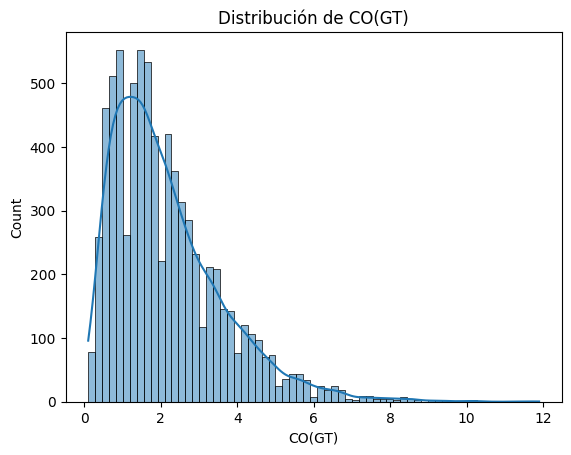

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["CO(GT)"], kde=True)
plt.title("Distribución de CO(GT)")
plt.show()

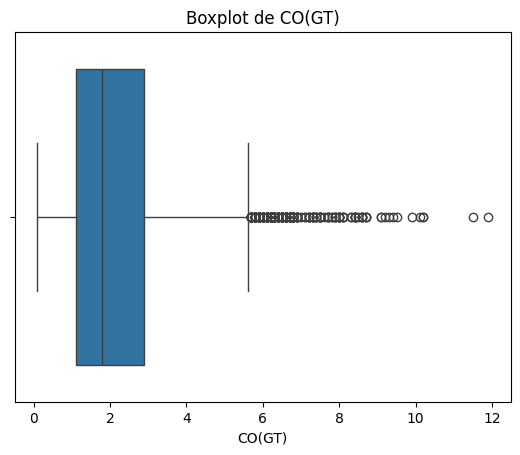

In [32]:
sns.boxplot(x=df["CO(GT)"])
plt.title("Boxplot de CO(GT)")
plt.show()

La distribución de CO(GT) es asimétrica hacia la derecha, indicando que la mayoría de valores son bajos.

El boxplot muestra la presencia de valores atípicos.

##Analisis Bivariado

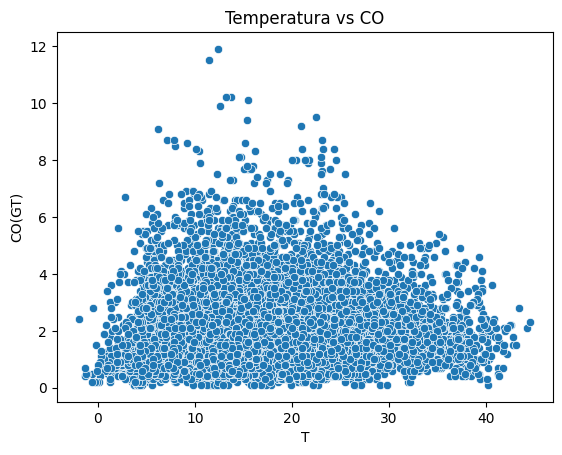

In [33]:
sns.scatterplot(x=df["T"], y=df["CO(GT)"])
plt.title("Temperatura vs CO")
plt.show()

No se observa una relación lineal fuerte entre temperatura y CO.
Ya que esto se encuentra presente en todas las temperaturas y con valores variables


##Analisis multivariado

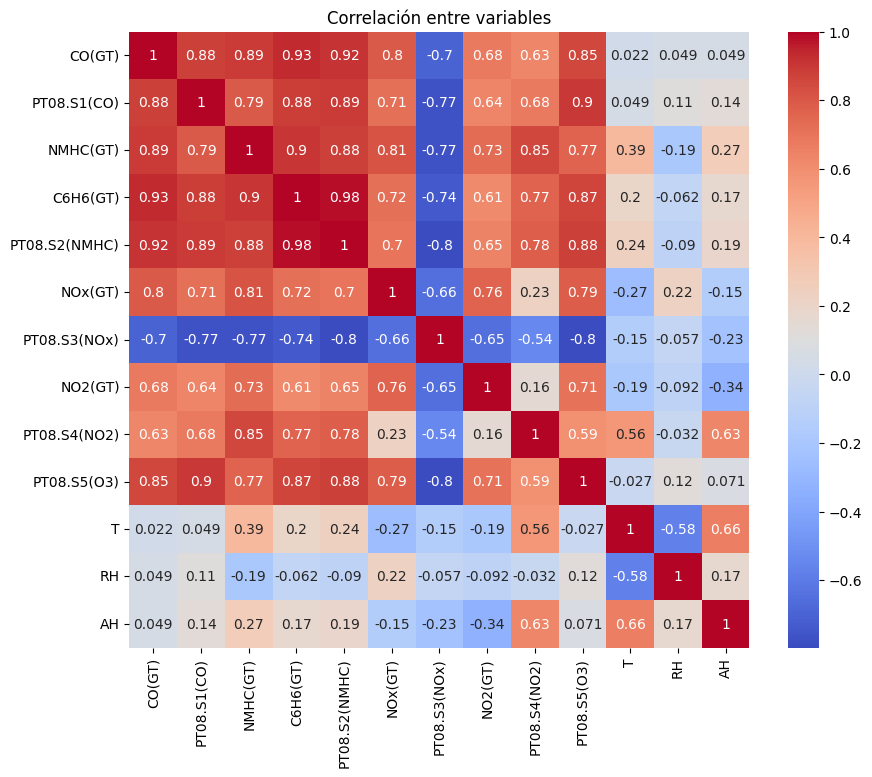

In [34]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación entre variables")
plt.show()

Se observa correlación entre CO(GT) y NOx(GT), así como entre C6H6(GT) y PT08.S2(NMHC).

Esto sugiere que algunos contaminantes están relacionados y pueden provenir de fuentes iguales de contaminacion.

## Identificación de patrones

### Patrones:
En las variables que se analizaron, como CO(GT), se observa una distribución sesgada, donde la mayoría de los valores son bajos pero existen algunos valores altos. Esto indica que los niveles de contaminación no son constantes y que hay momentos donde aumentan más de lo normal.

### Relaciones:
Existen correlaciones entre algunas variables contaminantes, lo que sugiere que tienden a comportarse de manera similar. Por ejemplo, cuando un contaminante aumenta, otro también puede hacerlo, lo que indica que podrían estar relacionados o depender de las mismas condiciones.

### Clusters:
No se observan clusters claros a simple vista en los gráficos. Los datos están algo dispersos, por lo que no se identifican grupos bien definidos sin aplicar técnicas más avanzadas.

### Outliers:
Se identificaron valores atípicos en variables como CO(GT), lo cual se pudo ver en el boxplot. Estos valores pueden representar picos reales de contaminación o posibles errores en la medición.

### Variables relevantes:
Las variables CO(GT), NOx(GT) y C6H6(GT) parecen ser las más importantes dentro del análisis realizado, ya que muestran variabilidad y algunas relaciones entre ellas.